# Final Project: Transfer Learning for Image Classification

This notebook completes the ten requested TensorFlow/Keras tasks with a reproducible five-class flower-image transfer-learning example. It uses the public, filtered dataset from the TensorFlow/Keras tutorials and an ImageNet-pretrained MobileNetV2 backbone. Training, validation, and test sets remain separate.

**Run in VS Code:** select the `.venv` Python kernel, then choose **Run All**. The first data/model-weight download may take a few minutes. The notebook saves downloaded assets under this project folder.

## Task 1 — Print the TensorFlow version

In [1]:
import os
from pathlib import Path
import certifi

# Keep model, image, and plotting caches inside this project folder.
PROJECT_ROOT = Path(".").resolve()
os.environ.setdefault("KERAS_HOME", str(PROJECT_ROOT / ".keras"))
os.environ.setdefault("MPLCONFIGDIR", str(PROJECT_ROOT / ".matplotlib"))
os.environ["SSL_CERT_FILE"] = certifi.where()
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import tensorflow as tf
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## Project setup and dataset

The supplied project folder contained no starter notebook or data, so this notebook downloads the public five-class TensorFlow flower_photos dataset. Images are split deterministically by class into disjoint 70% training, 15% validation, and 15% held-out test subsets.

In [2]:
import random
import tarfile
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras import layers, models

SEED = 42
IMAGE_SIZE = (160, 160)
BATCH_SIZE = 32
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_ROOT = Path("data")
DATA_ROOT.mkdir(parents=True, exist_ok=True)
FLOWERS_DIR = DATA_ROOT / "flower_photos"
DATA_URL = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
ARCHIVE = DATA_ROOT / "flower_photos.tgz"

if not (FLOWERS_DIR / "daisy").is_dir():
    if not ARCHIVE.exists():
        print("Downloading the public TensorFlow flower_photos dataset...")
        downloaded = tf.keras.utils.get_file(
            fname=ARCHIVE.name,
            origin=DATA_URL,
            cache_dir=str(DATA_ROOT.resolve()),
            cache_subdir="downloads",
            extract=False,
        )
        Path(downloaded).replace(ARCHIVE)
    print("Extracting dataset...")
    with tarfile.open(ARCHIVE, "r:gz") as archive:
        archive.extractall(DATA_ROOT, filter="data")

FLOWER_CLASS_NAMES = sorted(
    path.name for path in FLOWERS_DIR.iterdir() if path.is_dir()
)
if len(FLOWER_CLASS_NAMES) != 5:
    raise ValueError(f"Expected the five flower classes; found {FLOWER_CLASS_NAMES}")

# Make deterministic, disjoint 70/15/15 train/validation/test splits with
# symlinks so the images are not duplicated on disk.
SPLIT_ROOT = DATA_ROOT / "flower_splits"
for class_name in FLOWER_CLASS_NAMES:
    image_paths = sorted((FLOWERS_DIR / class_name).glob("*.jpg"))
    if not image_paths:
        raise FileNotFoundError(f"No JPEG images found for {class_name}")
    random.Random(f"{SEED}-{class_name}").shuffle(image_paths)
    train_end = int(len(image_paths) * 0.70)
    validation_end = train_end + int(len(image_paths) * 0.15)
    partitions = {
        "train": image_paths[:train_end],
        "validation": image_paths[train_end:validation_end],
        "test": image_paths[validation_end:],
    }
    for split_name, split_paths in partitions.items():
        destination = SPLIT_ROOT / split_name / class_name
        destination.mkdir(parents=True, exist_ok=True)
        for source_path in split_paths:
            link = destination / source_path.name
            if not link.exists():
                link.symlink_to(source_path.resolve())

print("Dataset ready at:", FLOWERS_DIR.resolve())
print("Class folders:", FLOWER_CLASS_NAMES)
for split_name in ("train", "validation", "test"):
    count = sum(1 for class_dir in (SPLIT_ROOT / split_name).iterdir() for path in class_dir.iterdir() if path.is_file())
    print(f"{split_name.title()} images: {count}")

Dataset ready at: /Users/prodbyjake_/Documents/final project/data/flower_photos
Class folders: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Train images: 2567
Validation images: 547
Test images: 556


## Task 2 — Create test_generator using test_datagen

The validation and test generators use disjoint dataset folders and the same MobileNetV2 preprocessing. The test iterator is not shuffled, so test image index 1 is repeatable.

In [3]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15, width_shift_range=0.10, height_shift_range=0.10,
    zoom_range=0.10, horizontal_flip=True,
)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    SPLIT_ROOT / "train", target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=True, seed=SEED,
)
validation_generator = test_datagen.flow_from_directory(
    SPLIT_ROOT / "validation", target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False,
)
# Task 2: create the held-out test_generator using test_datagen.
test_generator = test_datagen.flow_from_directory(
    SPLIT_ROOT / "test", target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False,
)

class_names = {index: name for name, index in train_generator.class_indices.items()}
print("Class mapping:", train_generator.class_indices)
print(
    "Train images:", train_generator.samples,
    "| validation images:", validation_generator.samples,
    "| test images:", test_generator.samples,
)

Found 2567 images belonging to 5 classes.


Found 547 images belonging to 5 classes.


Found 556 images belonging to 5 classes.


Class mapping: {'daisy': 0, 'dandelion': 1, 'roses': 2, 'sunflowers': 3, 'tulips': 4}
Train images: 2567 | validation images: 547 | test images: 556


## Task 3 — Print the length of `train_generator`

In [4]:
print("Length of train_generator (batches per epoch):", len(train_generator))

Length of train_generator (batches per epoch): 81


## Create the feature-extraction model

In [5]:
base_model = MobileNetV2(
    input_shape=IMAGE_SIZE + (3,), include_top=False, weights="imagenet"
)
base_model.trainable = False

inputs = layers.Input(shape=IMAGE_SIZE + (3,), name="image")
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = layers.Dropout(0.2, name="dropout")(x)
outputs = layers.Dense(
    len(FLOWER_CLASS_NAMES), activation="softmax", name="flower_class_probabilities"
)(x)
extract_feat_model = models.Model(inputs, outputs, name="extract_feat_model")

## Task 4 — Print the model summary

In [6]:
extract_feat_model.summary()

Model: "extract_feat_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flower_class_probabilities      │ (None, 5)              │         6,405 │
│ (Dense)                         │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Task 5 — Compile the model and train the feature-extraction head

In [7]:
extract_feat_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy", metrics=["accuracy"],
)

FEATURE_EPOCHS = 3
history_extract = extract_feat_model.fit(
    train_generator, validation_data=validation_generator,
    epochs=FEATURE_EPOCHS,
)

Epoch 1/3


W0000 00:00:1790500205.489868 1312550 cpu_utils.cc:145] Failed to get CPU frequency: 0 Hz
W0000 00:00:1790500205.493813 1312550 op_level_cost_estimator.cc:743] Invalid device specifications for CPU: goo.gle/debugproto   type: "CPU" model: "0" num_cores: 8 environment { key: "cpu_instruction_set" value: "ARM NEON" } environment { key: "eigen" value: "3.5.0" } l1_cache_size: 16384 l2_cache_size: 524288 l3_cache_size: 524288 memory_size: 268435456


 1/81 ━━━━━━━━━━━━━━━━━━━━ 2:31 2s/step - accuracy: 0.2500 - loss: 2.1318

 2/81 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - accuracy: 0.2031 - loss: 2.3923

 3/81 ━━━━━━━━━━━━━━━━━━━━ 8s 106ms/step - accuracy: 0.2396 - loss: 2.1502

...

78/81 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.8495 - loss: 0.4136

79/81 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.8494 - loss: 0.4150

80/81 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.8505 - loss: 0.4121

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.8500 - loss: 0.4118

81/81 ━━━━━━━━━━━━━━━━━━━━ 12s 143ms/step - accuracy: 0.8500 - loss: 0.4118 - val_accuracy: 0.8867 - val_loss: 0.3301


## Task 6 — Plot feature-extraction training and validation accuracy

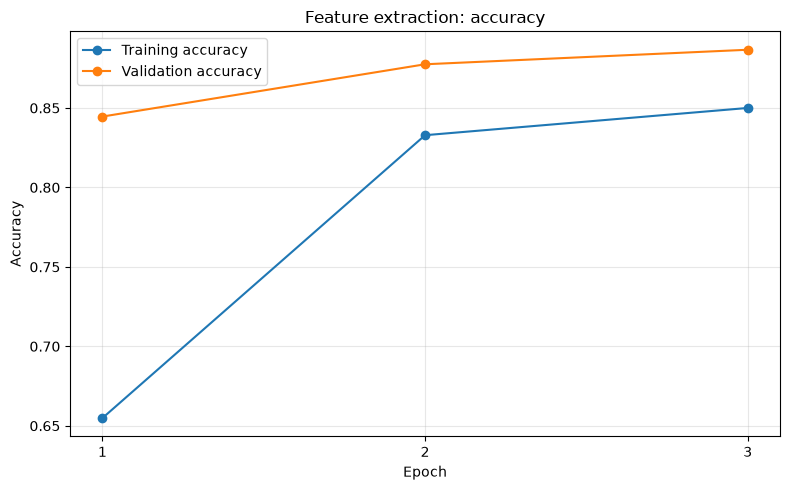

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(history_extract.history["accuracy"], marker="o", label="Training accuracy")
plt.plot(history_extract.history["val_accuracy"], marker="o", label="Validation accuracy")
plt.title("Feature extraction: accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(range(FEATURE_EPOCHS), range(1, FEATURE_EPOCHS + 1))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Fine-tune the final MobileNetV2 layers

The first training stage has already trained the new classification head. For fine-tuning, the final 30 backbone layers are unfrozen at a low learning rate; batch-normalization layers stay frozen to keep their pretrained statistics stable.

In [9]:
# Clone the trained feature-extraction model so its predictions remain available
# unchanged for Task 9 after the separate fine-tuning stage.
fine_tune_model = models.clone_model(extract_feat_model)
fine_tune_model.set_weights(extract_feat_model.get_weights())
fine_tune_base_model = fine_tune_model.get_layer(base_model.name)
fine_tune_base_model.trainable = True
for layer in fine_tune_base_model.layers[:-30]:
    layer.trainable = False
for layer in fine_tune_base_model.layers[-30:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

fine_tune_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy", metrics=["accuracy"],
)

FINE_TUNE_EPOCHS = 2
history_fine_tune = fine_tune_model.fit(
    train_generator, validation_data=validation_generator,
    epochs=FINE_TUNE_EPOCHS,
)

Epoch 1/2


W0000 00:00:1790500244.107130 1312550 op_level_cost_estimator.cc:743] Invalid device specifications for CPU: goo.gle/debugproto   type: "CPU" model: "0" num_cores: 8 environment { key: "cpu_instruction_set" value: "ARM NEON" } environment { key: "eigen" value: "3.5.0" } l1_cache_size: 16384 l2_cache_size: 524288 l3_cache_size: 524288 memory_size: 268435456


 1/81 ━━━━━━━━━━━━━━━━━━━━ 2:56 2s/step - accuracy: 0.8125 - loss: 0.4604

 2/81 ━━━━━━━━━━━━━━━━━━━━ 10s 134ms/step - accuracy: 0.8281 - loss: 0.5147

 3/81 ━━━━━━━━━━━━━━━━━━━━ 10s 135ms/step - accuracy: 0.8438 - loss: 0.5286

...

78/81 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.8952 - loss: 0.3072

79/81 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.8949 - loss: 0.3081

80/81 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.8935 - loss: 0.3111

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.8929 - loss: 0.3146

81/81 ━━━━━━━━━━━━━━━━━━━━ 14s 170ms/step - accuracy: 0.8929 - loss: 0.3146 - val_accuracy: 0.8976 - val_loss: 0.2884


## Task 7 — Plot fine-tuning training and validation loss

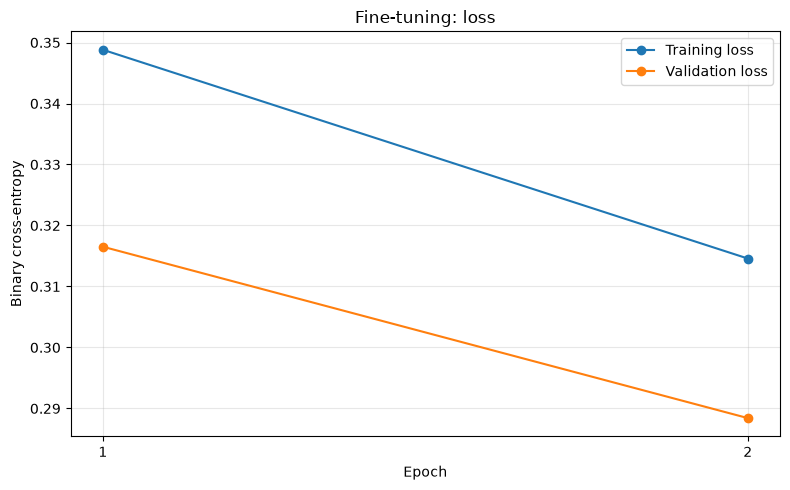

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(history_fine_tune.history["loss"], marker="o", label="Training loss")
plt.plot(history_fine_tune.history["val_loss"], marker="o", label="Validation loss")
plt.title("Fine-tuning: loss")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.xticks(range(FINE_TUNE_EPOCHS), range(1, FINE_TUNE_EPOCHS + 1))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Task 8 — Plot fine-tuning training and validation accuracy

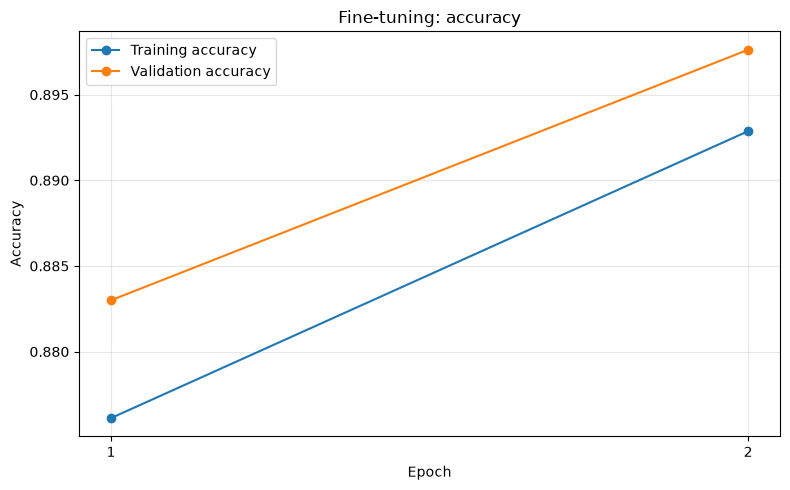

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(history_fine_tune.history["accuracy"], marker="o", label="Training accuracy")
plt.plot(history_fine_tune.history["val_accuracy"], marker="o", label="Validation accuracy")
plt.title("Fine-tuning: accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(range(FINE_TUNE_EPOCHS), range(1, FINE_TUNE_EPOCHS + 1))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Held-out test evaluation

In [12]:
test_loss, test_accuracy = fine_tune_model.evaluate(test_generator, verbose=1)
print(f"Held-out test loss: {test_loss:.4f}")
print(f"Held-out test accuracy: {test_accuracy:.2%}")

 1/18 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step - accuracy: 0.9688 - loss: 0.1699

 2/18 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step - accuracy: 0.9375 - loss: 0.2283

 3/18 ━━━━━━━━━━━━━━━━━━━━ 2s 161ms/step - accuracy: 0.8958 - loss: 0.3608

 4/18 ━━━━━━━━━━━━━━━━━━━━ 2s 149ms/step - accuracy: 0.8828 - loss: 0.3633

 5/18 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - accuracy: 0.9062 - loss: 0.3035

...

15/18 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.8896 - loss: 0.2939

16/18 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.8887 - loss: 0.2990

17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.8879 - loss: 0.3057

18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step - accuracy: 0.8885 - loss: 0.3030


Held-out test loss: 0.3030
Held-out test accuracy: 88.85%


## Task 9 — Plot test image 1 with the Extract Features Model

In [13]:
def plot_test_prediction(model, model_label, index_to_plot=1):
    if not 0 <= index_to_plot < test_generator.samples:
        raise IndexError(f"Test image index {index_to_plot} is out of range.")
    batch_index, within_batch = divmod(index_to_plot, BATCH_SIZE)
    images, labels = test_generator[batch_index]
    image = images[within_batch]
    true_index = int(np.argmax(labels[within_batch]))
    probabilities = model.predict(image[np.newaxis, ...], verbose=0)[0]
    predicted_index = int(np.argmax(probabilities))
    confidence = float(probabilities[predicted_index])
    display_image = np.clip(image * 127.5 + 127.5, 0, 255).astype("uint8")

    plt.figure(figsize=(6, 6))
    plt.imshow(display_image)
    plt.axis("off")
    plt.title(
        f"{model_label} — test index {index_to_plot}\n"
        f"True: {class_names[true_index]} | Predicted: "
        f"{class_names[predicted_index]} ({confidence:.1%})"
    )
    plt.tight_layout()
    plt.show()
    print(
        f"{model_label}: true={class_names[true_index]}, "
        f"predicted={class_names[predicted_index]}, confidence={confidence:.1%}"
    )

W0000 00:00:1790500274.709182 1312550 op_level_cost_estimator.cc:743] Invalid device specifications for CPU: goo.gle/debugproto   type: "CPU" model: "0" num_cores: 8 environment { key: "cpu_instruction_set" value: "ARM NEON" } environment { key: "eigen" value: "3.5.0" } l1_cache_size: 16384 l2_cache_size: 524288 l3_cache_size: 524288 memory_size: 268435456


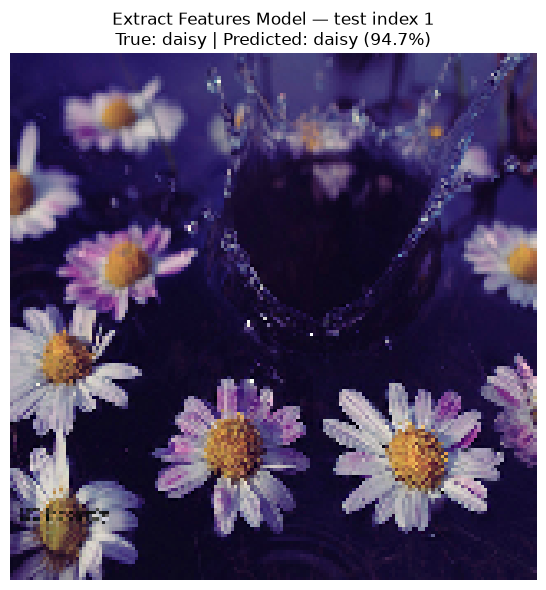

Extract Features Model: true=daisy, predicted=daisy, confidence=94.7%


In [14]:
index_to_plot = 1
plot_test_prediction(extract_feat_model, "Extract Features Model", index_to_plot=index_to_plot)

## Task 10 — Plot test image 1 with the Fine-Tuned Model

W0000 00:00:1790500275.194767 1312550 op_level_cost_estimator.cc:743] Invalid device specifications for CPU: goo.gle/debugproto   type: "CPU" model: "0" num_cores: 8 environment { key: "cpu_instruction_set" value: "ARM NEON" } environment { key: "eigen" value: "3.5.0" } l1_cache_size: 16384 l2_cache_size: 524288 l3_cache_size: 524288 memory_size: 268435456


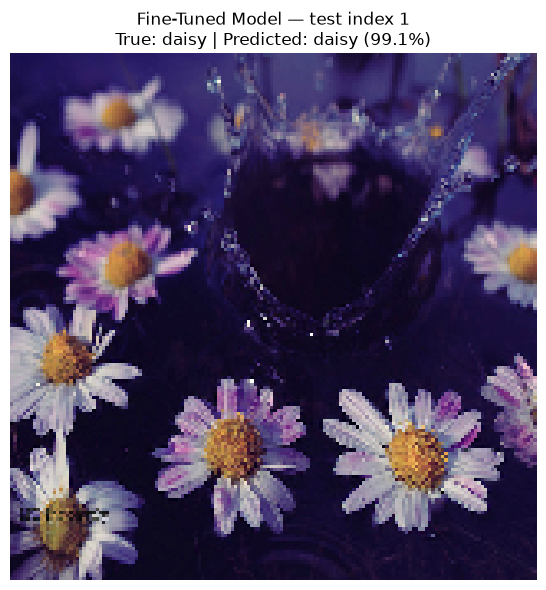

Fine-Tuned Model: true=daisy, predicted=daisy, confidence=99.1%


In [15]:
plot_test_prediction(fine_tune_model, "Fine-Tuned Model", index_to_plot=index_to_plot)

## Completion checklist

- TensorFlow version displayed.
- `test_generator` created from `test_datagen`.
- Training generator length printed.
- Model summary printed and model compiled.
- Feature-extraction accuracy and fine-tuning loss/accuracy plots produced.
- The same held-out test image at index 1 plotted with both model stages.